<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSGE603130 • Kecerdasan Artifisial dan Sains Data Dasar

Semester Gasal 2024/2025

Fakultas Ilmu Komputer, Universitas Indonesia

**TUGAS KELOMPOK Bing Chilling : *Cycling Segments Leaderboard (CSL)***

<br>
Farras Hafizhudin Indra Wijaya - 2106652682<br>
Arya Daniswara Khairan - 2106702781<br>
I Dewa Putu Aditya Rahman - 2106650456<br>
Ibni Shaquille Syauqi Ibrahim - 2106706735
<center>


## <span style="font-size: 30px; font-weight: bold;">Import Modul yang Dibutuhkan</span>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, silhouette_score, silhouette_samples
from sklearn.calibration import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer

## <span style="font-size: 30px; font-weight: bold;">Mendefine performance evaluation function untuk regressor</span>

In [2]:
def evaluate_regressor_performance(y_pred, y_test):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

## <span style="font-size: 30px; font-weight: bold;">Membaca Dataset, Membuang Duplikat, Memisahkan attempt_date menjadi 3 kolom</span>

In [ ]:
df_csl = pd.read_csv("train_csl.csv")
df_csl_copy = df_csl.copy()
df_csl_drop_dupe = df_csl_copy.drop_duplicates()

ordinal_features = ['user_age_group', 'user_weight_category']
numerical_features = ['smt_rank', 'smt_avg_spd', 'smt_finish_seconds', 'act_avg_spd', 
                      'act_max_spd', 'act_total_km', 'act_moving_seconds', 'act_total_seconds']
categorical_features = ['gender', 'smt_name', 'act_title']

df_csl_drop_dupe['attempt_date'] = pd.to_datetime(df_csl_drop_dupe['attempt_date'], errors='coerce')
df_csl_drop_dupe['year'] = df_csl_drop_dupe['attempt_date'].dt.year
df_csl_drop_dupe['month'] = df_csl_drop_dupe['attempt_date'].dt.month
df_csl_drop_dupe['day'] = df_csl_drop_dupe['attempt_date'].dt.day

# df_csl_drop_dupe.isnull().sum()
df_csl_drop_dupe.head()

,user_age_group,user_id,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id,year,month,day
0,25 to 34,1972,2017-12-22,male,712,15.8,382,Headquarters Business Park,54 kg and under,Night Ride,13.6,34.9,19.24,5103,5103,0,6977,2017,12,22
1,25 to 34,239,2015-04-13,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,Night Ride,21.5,43.2,23.47,3926,3926,0,3518,2015,4,13
2,25 to 34,405,2018-02-07,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,Evening Ride,26.7,92.9,38.23,5152,5152,0,415,2018,2,7
3,25 to 34,318,2018-08-24,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,Afternoon Ride,31.4,54.4,65.77,7548,7548,1,1755,2018,8,24
4,25 to 34,628,2020-03-06,female,19,21.3,284,Headquarters Business Park,54 kg and under,ثاني تمرين ١٠٠كم,19.9,43.2,96.53,17493,17493,0,7088,2020,3,6


## <span style="font-size: 30px; font-weight: bold;">Lanjutan Preprocessing, Imputasi missing values dengan KNN, dan persiapan training</span>

In [4]:
imputer = KNNImputer(n_neighbors=5)
label_encoder = LabelEncoder()

drop_target = ['smt_finish_seconds', 'id', 'user_id', 'attempt_date']

categorical_columns = df_csl_drop_dupe.select_dtypes(include=['object']).columns

for col in categorical_columns:
        df_csl_drop_dupe[col] = label_encoder.fit_transform(df_csl_drop_dupe[col])

X_kaggle = df_csl_drop_dupe.drop(drop_target, axis=1)
y_kaggle = df_csl_drop_dupe['smt_finish_seconds']

numerical_features = ['smt_rank', 'smt_avg_spd', 'act_avg_spd', 'act_max_spd', 'act_total_km', 'act_moving_seconds', 'act_total_seconds']

X_kaggle[numerical_features] = imputer.fit_transform(X_kaggle[numerical_features])

X_train_kaggle, X_test_kaggle, y_train_kaggle, y_test_kaggle = train_test_split(X_kaggle, y_kaggle, train_size=0.80, test_size=0.20, random_state=2025)
X_kaggle.head()

,user_age_group,gender,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,year,month,day
0,2,1,712.0,15.8,1,2,505,13.6,34.9,19.24,5103.0,5103.0,0,2017,12,22
1,2,1,189.0,33.2,5,0,505,21.5,43.2,23.47,3926.0,3926.0,0,2015,4,13
2,2,1,264.0,23.7,8,5,218,26.7,92.9,38.23,5152.0,5152.0,0,2018,2,7
3,2,1,50.0,33.4,0,5,127,31.4,54.4,65.77,7548.0,7548.0,1,2018,8,24
4,2,0,19.0,21.3,1,2,916,19.9,43.2,96.53,17493.0,17493.0,0,2020,3,6


## <span style="font-size: 30px; font-weight: bold;">Perbandingan 6 model training dengan fungsi evaluate sebelumnya</span>

In [5]:
gnb = GaussianNB()
gnb.fit(X_train_kaggle, y_train_kaggle)
y_pred_kaggle = gnb.predict(X_test_kaggle)

print("Model - Gaussian Naive Bayes")
evaluate_regressor_performance(y_pred_kaggle, y_test_kaggle)
print()

#

random_forest_model = RandomForestRegressor(max_depth=3, n_estimators=50, random_state=2024)
random_forest_model.fit(X_train_kaggle, y_train_kaggle)
y_pred_kaggle = random_forest_model.predict(X_test_kaggle)

print("=====================================================")
print("Model - Random Forest")
evaluate_regressor_performance(y_pred_kaggle, y_test_kaggle)
print()

##

svm = SVR()
svm.fit(X_train_kaggle, y_train_kaggle)

y_pred_kaggle = svm.predict(X_test_kaggle)

print("=====================================================")
print("Model - Support Vector Machine")
evaluate_regressor_performance(y_pred_kaggle, y_test_kaggle)
print()

##

lgbm = LGBMRegressor()
lgbm.fit(X_train_kaggle, y_train_kaggle)

y_pred_kaggle = lgbm.predict(X_test_kaggle)

print("=====================================================")
print("Model - Light Gradient-Boosting Machine")
evaluate_regressor_performance(y_pred_kaggle, y_test_kaggle)
print()

##

xgboost = XGBRegressor()
xgboost.fit(X_train_kaggle, y_train_kaggle)
y_pred_kaggle = xgboost.predict(X_test_kaggle)

print("=====================================================")
print("Model - Extreme Gradient Boosting")
evaluate_regressor_performance(y_pred_kaggle, y_test_kaggle)
print()

#

catboost = CatBoostRegressor()
catboost.fit(X_train_kaggle, y_train_kaggle, verbose=False)
y_pred_kaggle = catboost.predict(X_test_kaggle)

print("=====================================================")
print("Model - CatBoost")
evaluate_regressor_performance(y_pred_kaggle, y_test_kaggle)
print()

Model - Gaussian Naive Bayes
Mean Absolute Error (MAE): 350.2081
Mean Squared Error (MSE): 324016.5973
Root Mean Squared Error (RMSE): 569.2246
R² Score: -0.4387

Model - Random Forest
Mean Absolute Error (MAE): 179.4193
Mean Squared Error (MSE): 89146.4824
Root Mean Squared Error (RMSE): 298.5741
R² Score: 0.6042

Model - Support Vector Machine
Mean Absolute Error (MAE): 252.8408
Mean Squared Error (MSE): 232932.7859
Root Mean Squared Error (RMSE): 482.6311
R² Score: -0.0343

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2087
[LightGBM] [Info] Number of data points in the train set: 5033, number of used features: 16
[LightGBM] [Info] Start training from score 531.932843
Model - Light Gradient-Boosting Machine
Mean Absolute Error (MAE): 26.0489
Mean Squared Error (MSE): 43738.1087

## <span style="font-size: 30px; font-weight: bold;">Preparation untuk data testing, preprocessing & prediction dengan model catboost</span>

In [6]:
df_csl_test = pd.read_csv("test_csl_reg_x.csv")
df_csl_copy = df_csl_test.copy()

df_csl_copy['attempt_date'] = pd.to_datetime(df_csl_copy['attempt_date'], errors='coerce')
df_csl_copy['year'] = df_csl_copy['attempt_date'].dt.year
df_csl_copy['month'] = df_csl_copy['attempt_date'].dt.month
df_csl_copy['day'] = df_csl_copy['attempt_date'].dt.day

df_csl_copy[numerical_features] = imputer.transform(df_csl_copy[numerical_features])

categorical_columns = df_csl_copy.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df_csl_copy[col] = label_encoder.fit_transform(df_csl_copy[col])

X_test_kaggle = df_csl_copy.drop(columns=['id', 'user_id', 'attempt_date'], axis=1)

cols = list(X_test_kaggle.columns)
cols.insert(1, cols.pop(cols.index('gender')))
X_test_kaggle = X_test_kaggle[cols]

y_pred_kaggle = catboost.predict(X_test_kaggle)

X_test_kaggle.head()

,user_age_group,gender,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,year,month,day
0,2,1,33.0,36.9,6,4,75,34.6,50.8,41.61,4326.0,4326.0,0,2018,7,15
1,2,1,181.0,26.2,8,5,105,25.4,40.3,45.37,6427.0,6427.0,0,2018,1,3
2,2,1,3.0,56.0,5,2,11,22.6,85.3,78.45,12507.0,12507.0,0,2019,7,19
3,4,1,142.0,11.1,3,5,63,12.1,16.9,21.01,6254.0,6254.0,0,2018,6,22
4,3,1,216.0,22.2,8,6,135,21.9,45.7,57.15,9398.0,9398.0,0,2018,8,29


## <span style="font-size: 30px; font-weight: bold;">Preparation untuk file admission kaggle</span>

In [7]:
kaggle_file_admission = pd.DataFrame({
    "id": df_csl_copy["id"],
    "smt_finish_seconds": y_pred_kaggle
})
kaggle_file_admission.to_csv("regression_csl_admission_result_bingchilling.csv", index=False)

## <span style="font-size: 30px; font-weight: bold;">*COMPLEMENTARY* | Testing dengan dataset real</span>

In [8]:
df_og = pd.read_csv('merge_regression.csv')

smt_finish_seconds_feat = df_og['smt_finish_seconds']

y_pred_kaggle = gnb.predict(X_test_kaggle)

#

print("Model - Gaussian Naive Bayes")
evaluate_regressor_performance(y_pred_kaggle, smt_finish_seconds_feat)
print()

#

y_pred_kaggle = random_forest_model.predict(X_test_kaggle)

print("=====================================================")
print("Model - Random Forest")
evaluate_regressor_performance(y_pred_kaggle, smt_finish_seconds_feat)
print()

##

y_pred_kaggle = svm.predict(X_test_kaggle)

print("=====================================================")
print("Model - Support Vector Machine")
evaluate_regressor_performance(y_pred_kaggle, smt_finish_seconds_feat)
print()

##

y_pred_kaggle = lgbm.predict(X_test_kaggle)

print("=====================================================")
print("Model - Light Gradient-Boosting Machine")
evaluate_regressor_performance(y_pred_kaggle, smt_finish_seconds_feat)
print()

##

y_pred_kaggle = xgboost.predict(X_test_kaggle)

print("=====================================================")
print("Model - Extreme Gradient Boosting")
evaluate_regressor_performance(y_pred_kaggle, smt_finish_seconds_feat)
print()

#

y_pred_kaggle = catboost.predict(X_test_kaggle)

print("=====================================================")
print("Model - CatBoost")
evaluate_regressor_performance(y_pred_kaggle, smt_finish_seconds_feat)
print()

Model - Gaussian Naive Bayes
Mean Absolute Error (MAE): 298.1487
Mean Squared Error (MSE): 306847.6328
Root Mean Squared Error (RMSE): 553.9383
R² Score: -0.0549

Model - Random Forest
Mean Absolute Error (MAE): 188.9991
Mean Squared Error (MSE): 146964.8167
Root Mean Squared Error (RMSE): 383.3599
R² Score: 0.4947

Model - Support Vector Machine
Mean Absolute Error (MAE): 262.5853
Mean Squared Error (MSE): 300883.1131
Root Mean Squared Error (RMSE): 548.5281
R² Score: -0.0344

Model - Light Gradient-Boosting Machine
Mean Absolute Error (MAE): 31.6066
Mean Squared Error (MSE): 83686.5515
Root Mean Squared Error (RMSE): 289.2863
R² Score: 0.7123

Model - Extreme Gradient Boosting
Mean Absolute Error (MAE): 27.6978
Mean Squared Error (MSE): 74432.5253
Root Mean Squared Error (RMSE): 272.8232
R² Score: 0.7441

Model - CatBoost
Mean Absolute Error (MAE): 24.0793
Mean Squared Error (MSE): 74473.3513
Root Mean Squared Error (RMSE): 272.8981
R² Score: 0.7440



## <span style="font-size: 30px; font-weight: bold;">Clustering</span>

In [9]:
age = df_csl_copy['user_age_group'].unique()
print(sorted(age))

weight = df_csl_copy['user_weight_category'].unique()
print(sorted(weight))

X = df_csl_drop_dupe[['user_age_group', 'user_weight_category', 'act_avg_spd']].copy()

[0, 1, 2, 3, 4, 5, 6, 7]
[0, 1, 2, 3, 4, 5, 6, 7, 8]


For n_clusters = 2 The average silhouette_coefficient is : 0.4533643725719062
For n_clusters = 3 The average silhouette_coefficient is : 0.36412234901437107
For n_clusters = 4 The average silhouette_coefficient is : 0.31247952377961724
For n_clusters = 5 The average silhouette_coefficient is : 0.3359011755701254


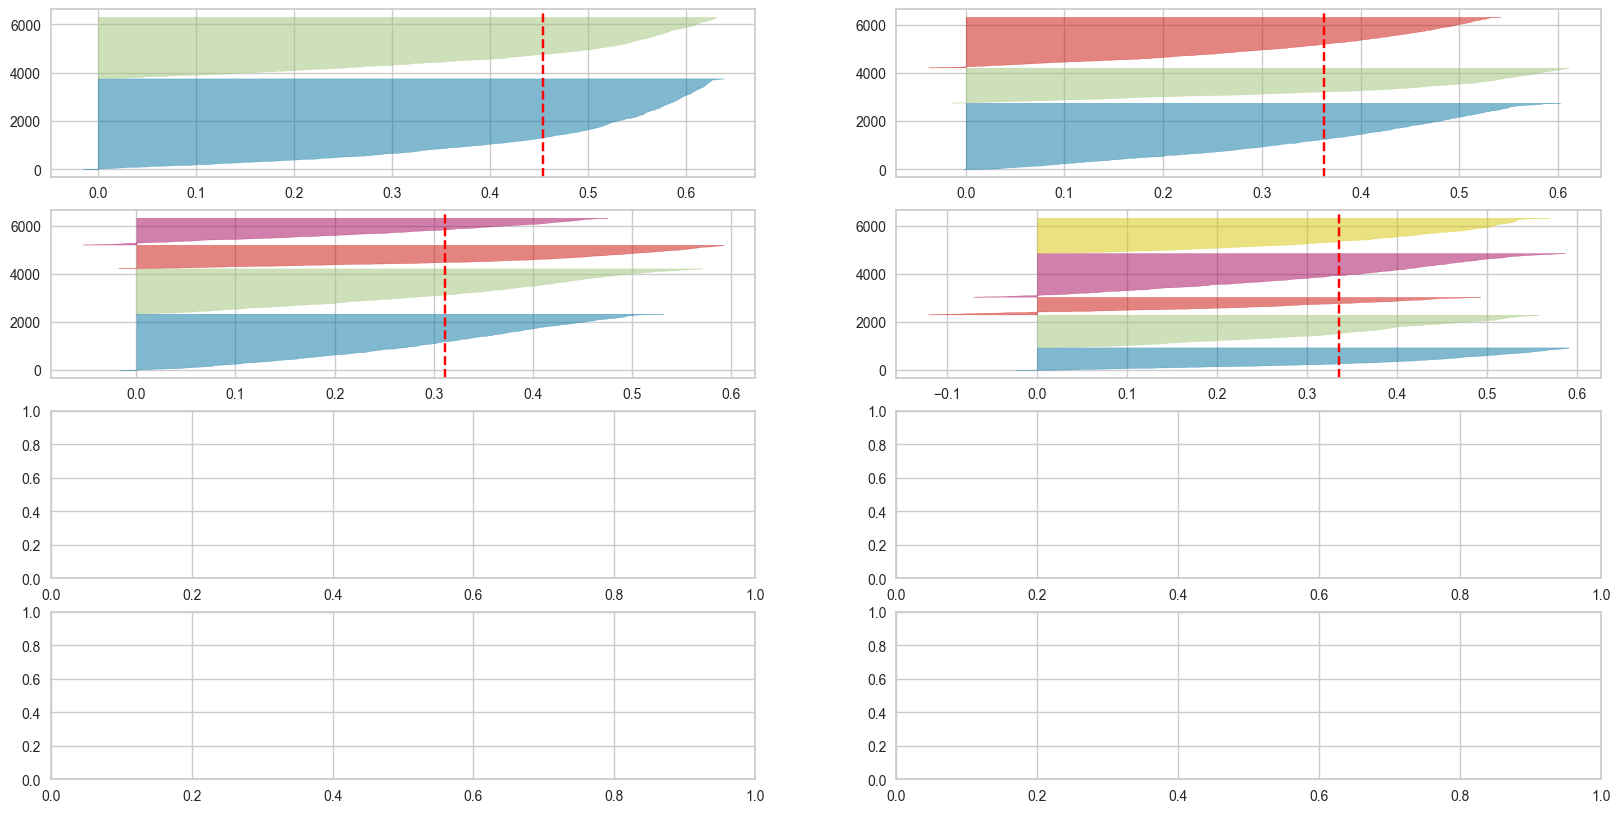

In [10]:
num_of_cluster = [2, 3, 4, 5]

fig, ax = plt.subplots(4, 2, figsize=(20,10))
for k in num_of_cluster:
    clusterer = KMeans(n_clusters = k, n_init=10)

    q, mod = divmod(k, 2)
    visualizer = SilhouetteVisualizer(clusterer, colors = 'yellowbrick', ax = ax[q-1][mod])
    visualizer.fit(X)

    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        k,
        "The average silhouette_coefficient is :",
        silhouette_avg,
    )

Berdasarkan hasil plotting di atas, jumlah cluster yang dipilih adalah n_clusters=2 karena memiliki average silhoutte coffiecient tertinggi dibanding lainnya yaitu 0.45

In [11]:
kmeans = KMeans(n_clusters=2)

cluster_assignment = kmeans.fit_predict(X)
data_with_clusters = pd.DataFrame(X.copy(), columns=('user_age_group', 'user_weight_category', 'act_avg_spd'))
data_with_clusters['Clusters'] = cluster_assignment
data_with_clusters

,user_age_group,user_weight_category,act_avg_spd,Clusters
0,2,2,13.6,0
1,2,0,21.5,0
2,2,5,26.7,1
3,2,5,31.4,1
4,2,2,19.9,0
...,...,...,...,...
6287,2,8,17.9,0
6288,3,6,34.5,1
6289,3,5,17.6,0
6290,3,6,14.5,0


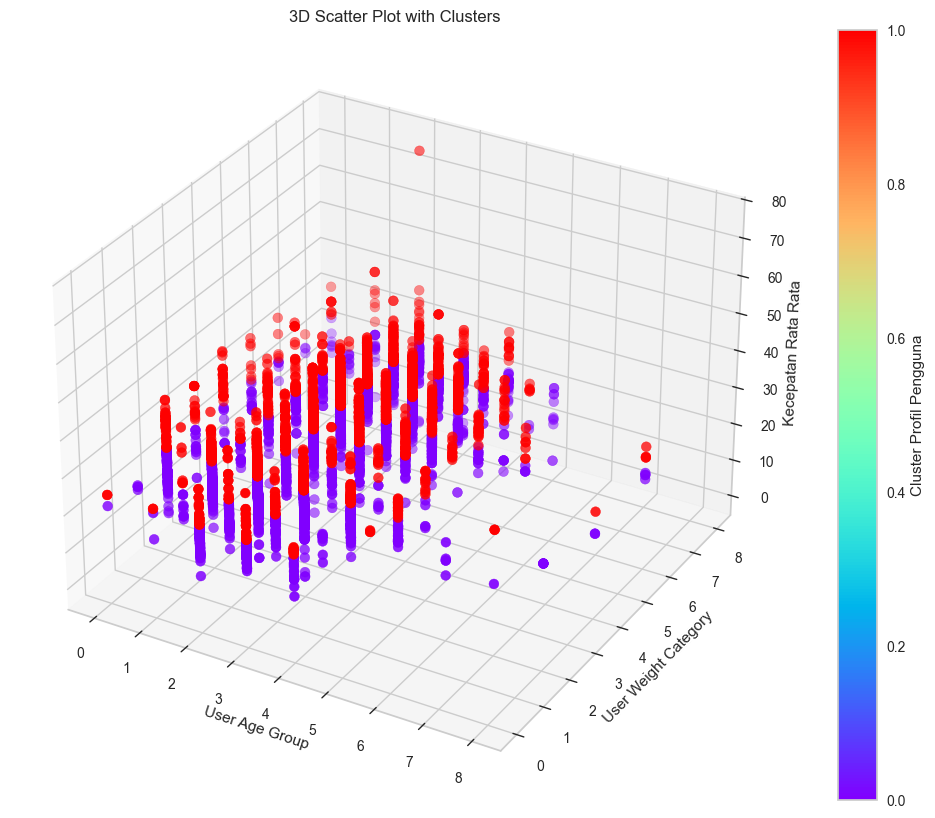

In [12]:
x = data_with_clusters['user_age_group']
y = data_with_clusters['user_weight_category']
z = data_with_clusters['act_avg_spd']
cluster = data_with_clusters['Clusters']

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z, c=cluster, cmap='rainbow', s=50)

ax.set_xlabel('User Age Group')
ax.set_ylabel('User Weight Category')
ax.set_zlabel('Kecepatan Rata Rata')
ax.set_title('3D Scatter Plot with Clusters')

color_bar = plt.colorbar(scatter)
color_bar.set_label('Cluster Profil Pengguna')

plt.show()

Dari hasil clustering diatas, dapat dilihat bahwa untuk yang tergolong **1 atau merah** memiliki **threshold "act_avg_spd" > 25.0** sedangkan untuk yang tergolong **0 atau ungu** memiliki **threshold "act_avg_spd" < 25.0**. Dari distribusi clusteringnya juga tidak terdapat partisipan atau pengguna yang tergolong paling muda (yaitu nilai 0 atau 19 and under) dan sekaligus tergolong least weighted (54 kg and under) secara berat badan.